# Обучение без учителя: снижение размерности и кластеризация
## Датасет: High Popularity Spotify Data

**Задача:** кластеризация музыкальных треков по аудиохарактеристикам.

**План работы:**
1. Загрузка и подготовка данных → датасет **D1**
2. Снижение размерности методом **PCA** → датасет **D2**
3. Снижение размерности методом **t-SNE** → датасет **D3**
4. Визуализация D2 и D3
5. Кластеризация D1, D2, D3 тремя методами: **K-Means**, **DBSCAN**, **Agglomerative Clustering**
6. Оценка качества: **Silhouette Score**, **Davies-Bouldin Index**, **Calinski-Harabasz Index**

## 1. Импорт библиотек

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Библиотеки успешно импортированы')

Библиотеки успешно импортированы


## 2. Загрузка и подготовка датасета → D1

In [10]:
df = pd.read_csv('high_popularity_spotify_data.csv')
print(f'Размер датасета: {df.shape}')
df.head(3)

Размер датасета: (1686, 29)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.308,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.200,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.214,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [11]:
# Отбираем числовые аудиохарактеристики треков (>2 признаков, без целевого track_popularity)
audio_features = [
    'energy',        # интенсивность трека
    'tempo',         # темп (BPM)
    'danceability',  # танцевальность
    'loudness',      # громкость (dB)
    'liveness',      # живое выступление vs студия
    'valence',       # позитивность/настроение
    'speechiness',   # доля речи
    'instrumentalness', # инструментальность
    'acousticness',  # акустичность
    'duration_ms',   # длительность
]

D1_raw = df[audio_features].copy()

print(f'Датасет D1: {D1_raw.shape[0]} треков, {D1_raw.shape[1]} признаков')
print(f'Пропуски: {D1_raw.isnull().sum().sum()}')
D1_raw.describe().round(3)

Датасет D1: 1686 треков, 10 признаков
Пропуски: 0


,energy,tempo,danceability,loudness,liveness,valence,speechiness,instrumentalness,acousticness,duration_ms
count,1686.000,1686.000,1686.000,1686.000,1686.000,1686.000,1686.000,1686.000,1686.000,1686.000
mean,0.667,121.071,0.650,-6.704,0.172,0.526,0.101,0.042,0.221,214562.126
std,0.185,27.066,0.158,3.377,0.124,0.236,0.100,0.157,0.251,58310.748
min,0.002,49.305,0.136,-43.643,0.021,0.035,0.023,0.000,0.000,61673.000
25%,0.551,100.059,0.543,-7.950,0.093,0.339,0.038,0.000,0.023,176607.750
50%,0.689,120.001,0.665,-5.974,0.121,0.528,0.058,0.000,0.124,211180.000
75%,0.807,136.834,0.769,-4.687,0.210,0.720,0.118,0.001,0.335,244993.250
max,0.990,209.688,0.979,1.295,0.950,0.978,0.848,0.971,0.995,547107.000


In [12]:
# Масштабирование — обязательно перед PCA и кластеризацией
scaler = StandardScaler()
D1 = scaler.fit_transform(D1_raw)
D1 = pd.DataFrame(D1, columns=audio_features)

print('D1 после стандартизации (первые 3 строки):')
print(D1.head(3).round(3))
print(f'\nМинимум: {D1.values.min():.2f}, Максимум: {D1.values.max():.2f}')

D1 после стандартизации (первые 3 строки):
   energy  tempo  danceability  loudness  liveness  valence  speechiness  \
0  -0.407  1.364        -0.820    -0.318    -0.400    0.039       -0.707   
1  -0.867 -0.595         0.613    -1.027    -0.440   -0.372       -0.653   
2   0.762 -0.463        -0.611     0.751    -0.102   -0.651       -0.643   

   instrumentalness  acousticness  duration_ms  
0            -0.265         0.346        0.637  
1             0.123        -0.085       -0.072  
2            -0.265        -0.029       -0.828  

Минимум: -10.94, Максимум: 7.49


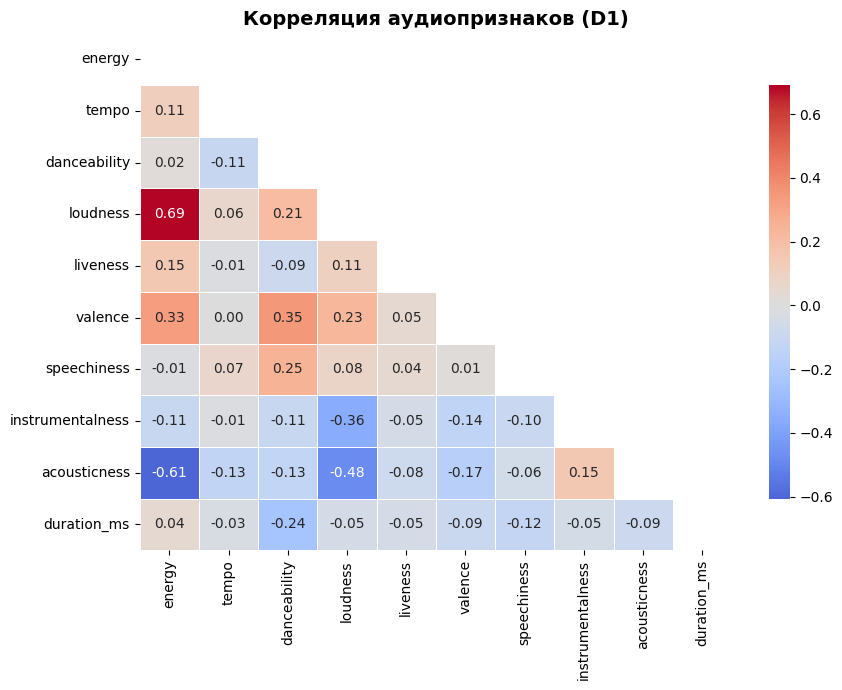

In [13]:
# Тепловая карта корреляций признаков D1
fig, ax = plt.subplots(figsize=(9, 7))
corr = D1.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Корреляция аудиопризнаков (D1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Снижение размерности: PCA → D2

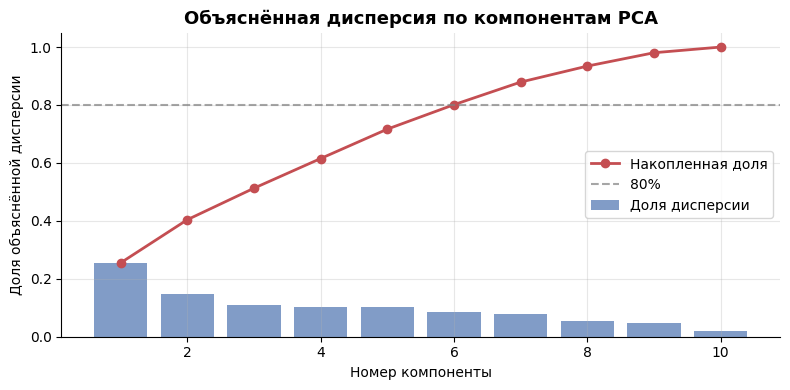

Первые 2 компоненты объясняют: 40.4% дисперсии
Первые 4 компоненты объясняют: 61.5% дисперсии


In [14]:
# Сначала посмотрим, сколько дисперсии объясняют компоненты
pca_full = PCA(random_state=42)
pca_full.fit(D1)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained)+1), explained, alpha=0.7,
       color='#4C72B0', label='Доля дисперсии')
ax.plot(range(1, len(cumulative)+1), cumulative, 'o-',
        color='#C44E52', linewidth=2, label='Накопленная доля')
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.7, label='80%')
ax.set_xlabel('Номер компоненты')
ax.set_ylabel('Доля объяснённой дисперсии')
ax.set_title('Объяснённая дисперсия по компонентам PCA', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Первые 2 компоненты объясняют: {cumulative[1]:.1%} дисперсии')
print(f'Первые 4 компоненты объясняют: {cumulative[3]:.1%} дисперсии')

In [15]:
# Снижаем до 2 компонент
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)
D2 = pd.DataFrame(D2, columns=['PC1', 'PC2'])

print(f'Датасет D2 (PCA): {D2.shape}')
print(f'PC1 объясняет: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 объясняет: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Итого:         {sum(pca.explained_variance_ratio_):.1%}')

Датасет D2 (PCA): (1686, 2)
PC1 объясняет: 25.5%
PC2 объясняет: 14.9%
Итого:         40.4%


## 4. Снижение размерности: t-SNE → D3

In [16]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    max_iter=1000,
    random_state=42
)
D3 = tsne.fit_transform(D1)
D3 = pd.DataFrame(D3, columns=['TSNE1', 'TSNE2'])

print(f'Датасет D3 (t-SNE): {D3.shape}')

Датасет D3 (t-SNE): (1686, 2)


## 5. Визуализация D2 и D3

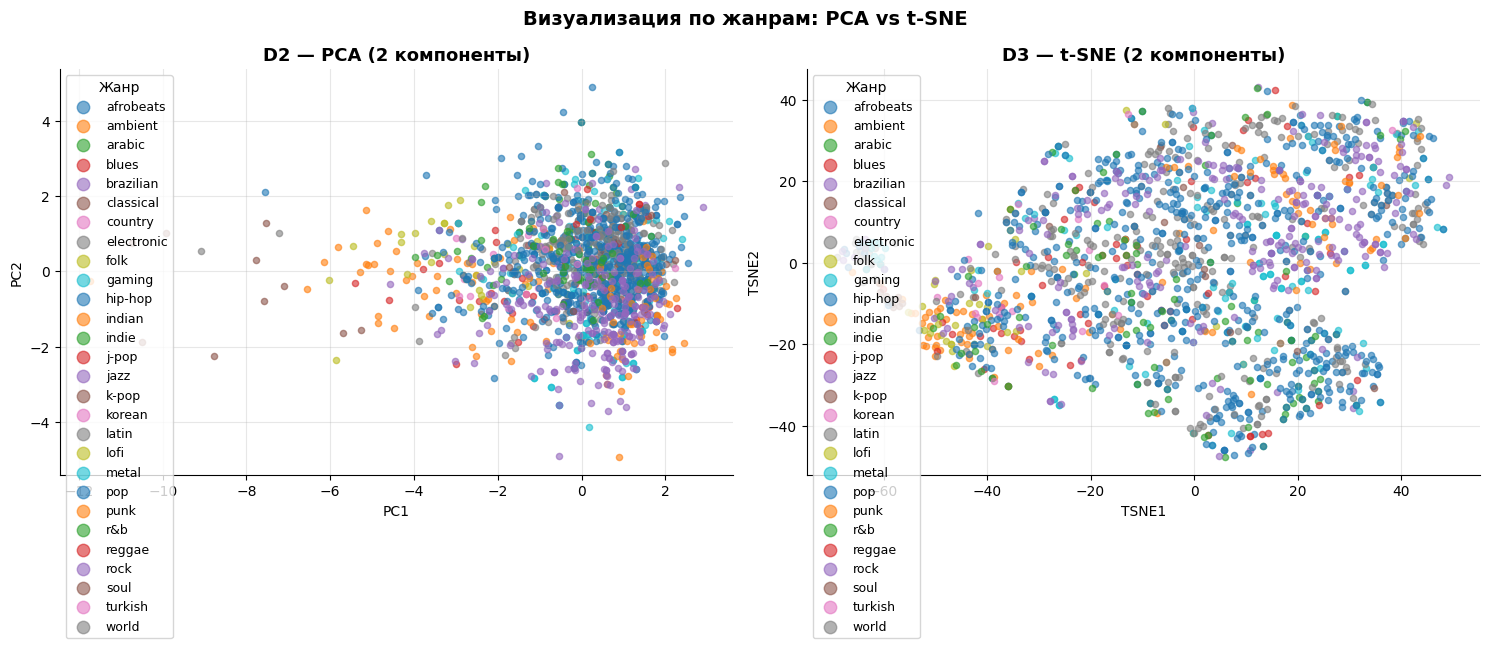

Вывод: t-SNE, как правило, выделяет кластеры более явно за счёт
нелинейного отображения локальных структур данных.


In [17]:
# Для раскраски используем жанр трека
genre = df['playlist_genre'].values
genres_unique = sorted(set(genre))
palette = sns.color_palette('tab10', n_colors=len(genres_unique))
color_map = {g: palette[i] for i, g in enumerate(genres_unique)}
colors = [color_map[g] for g in genre]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# D2 — PCA
for g in genres_unique:
    mask = genre == g
    axes[0].scatter(D2.loc[mask, 'PC1'], D2.loc[mask, 'PC2'],
                    c=[color_map[g]], label=g, alpha=0.6, s=20)
axes[0].set_title('D2 — PCA (2 компоненты)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='Жанр', markerscale=2, fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# D3 — t-SNE
for g in genres_unique:
    mask = genre == g
    axes[1].scatter(D3.loc[mask, 'TSNE1'], D3.loc[mask, 'TSNE2'],
                    c=[color_map[g]], label=g, alpha=0.6, s=20)
axes[1].set_title('D3 — t-SNE (2 компоненты)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('TSNE1')
axes[1].set_ylabel('TSNE2')
axes[1].legend(title='Жанр', markerscale=2, fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Визуализация по жанрам: PCA vs t-SNE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print('Вывод: t-SNE, как правило, выделяет кластеры более явно за счёт')
print('нелинейного отображения локальных структур данных.')

## 6. Выбор оптимального числа кластеров (метод локтя)

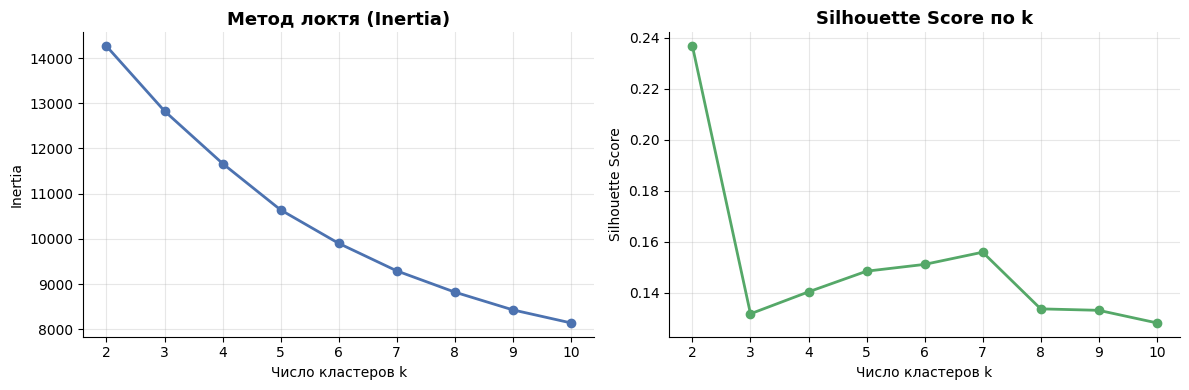

Оптимальное число кластеров по Silhouette: k = 2


In [18]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(D1)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(D1, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'o-', color='#4C72B0', linewidth=2)
axes[0].set_title('Метод локтя (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Число кластеров k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(k_range, silhouettes, 'o-', color='#55A868', linewidth=2)
axes[1].set_title('Silhouette Score по k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Число кластеров k')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouettes)]
print(f'Оптимальное число кластеров по Silhouette: k = {best_k}')

## 7. Кластеризация D1, D2, D3 тремя методами

In [19]:
N_CLUSTERS = best_k

datasets = {'D1 (исходный, 10 признаков)': D1.values,
            'D2 (PCA, 2 признака)': D2.values,
            'D3 (t-SNE, 2 признака)': D3.values}

# Параметры DBSCAN подбираем отдельно под каждый датасет
dbscan_params = {
    'D1 (исходный, 10 признаков)': {'eps': 2.0, 'min_samples': 10},
    'D2 (PCA, 2 признака)':        {'eps': 0.8, 'min_samples': 10},
    'D3 (t-SNE, 2 признака)':      {'eps': 5.0, 'min_samples': 10},
}

def evaluate(X, labels):
    """Считает метрики, возвращает None если кластеров < 2."""
    unique = set(labels) - {-1}
    if len(unique) < 2:
        return None, None, None
    # Убираем шумовые точки DBSCAN (label == -1) для метрик
    mask = labels != -1
    X_clean, labels_clean = X[mask], labels[mask]
    if len(set(labels_clean)) < 2:
        return None, None, None
    sil = silhouette_score(X_clean, labels_clean)
    db  = davies_bouldin_score(X_clean, labels_clean)
    ch  = calinski_harabasz_score(X_clean, labels_clean)
    return sil, db, ch

results = []

for ds_name, X in datasets.items():
    # 1. K-Means
    km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    lbl_km = km.fit_predict(X)
    sil, db, ch = evaluate(X, lbl_km)
    results.append({'Датасет': ds_name, 'Метод': 'K-Means',
                    'Кластеров': N_CLUSTERS,
                    'Silhouette↑': sil, 'Davies-Bouldin↓': db,
                    'Calinski-Harabasz↑': ch})

    # 2. DBSCAN
    params = dbscan_params[ds_name]
    db_model = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    lbl_db = db_model.fit_predict(X)
    n_clusters_db = len(set(lbl_db) - {-1})
    n_noise = (lbl_db == -1).sum()
    sil, db_s, ch = evaluate(X, lbl_db)
    results.append({'Датасет': ds_name, 'Метод': f'DBSCAN (k={n_clusters_db}, шум={n_noise})',
                    'Кластеров': n_clusters_db,
                    'Silhouette↑': sil, 'Davies-Bouldin↓': db_s,
                    'Calinski-Harabasz↑': ch})

    # 3. Agglomerative Clustering
    agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
    lbl_agg = agg.fit_predict(X)
    sil, db_a, ch = evaluate(X, lbl_agg)
    results.append({'Датасет': ds_name, 'Метод': 'Agglomerative',
                    'Кластеров': N_CLUSTERS,
                    'Silhouette↑': sil, 'Davies-Bouldin↓': db_a,
                    'Calinski-Harabasz↑': ch})

results_df = pd.DataFrame(results)
results_df[['Silhouette↑', 'Davies-Bouldin↓', 'Calinski-Harabasz↑']] = \
    results_df[['Silhouette↑', 'Davies-Bouldin↓', 'Calinski-Harabasz↑']].round(4)

print('Результаты кластеризации:')
print(results_df.to_string(index=False))

Результаты кластеризации:
                    Датасет                 Метод  Кластеров  Silhouette↑  Davies-Bouldin↓  Calinski-Harabasz↑
D1 (исходный, 10 признаков)               K-Means          2       0.2367           1.8391            306.5154
D1 (исходный, 10 признаков) DBSCAN (k=1, шум=189)          1          NaN              NaN                 NaN
D1 (исходный, 10 признаков)         Agglomerative          2       0.2801           1.9889            255.5482
       D2 (PCA, 2 признака)               K-Means          2       0.4498           0.9341           1010.6150
       D2 (PCA, 2 признака)  DBSCAN (k=1, шум=29)          1          NaN              NaN                 NaN
       D2 (PCA, 2 признака)         Agglomerative          2       0.4763           0.8475            987.4204
     D3 (t-SNE, 2 признака)               K-Means          2       0.3908           0.9744           1373.9367
     D3 (t-SNE, 2 признака)  DBSCAN (k=1, шум=15)          1          NaN             

## 8. Визуализация кластеров на D2 и D3

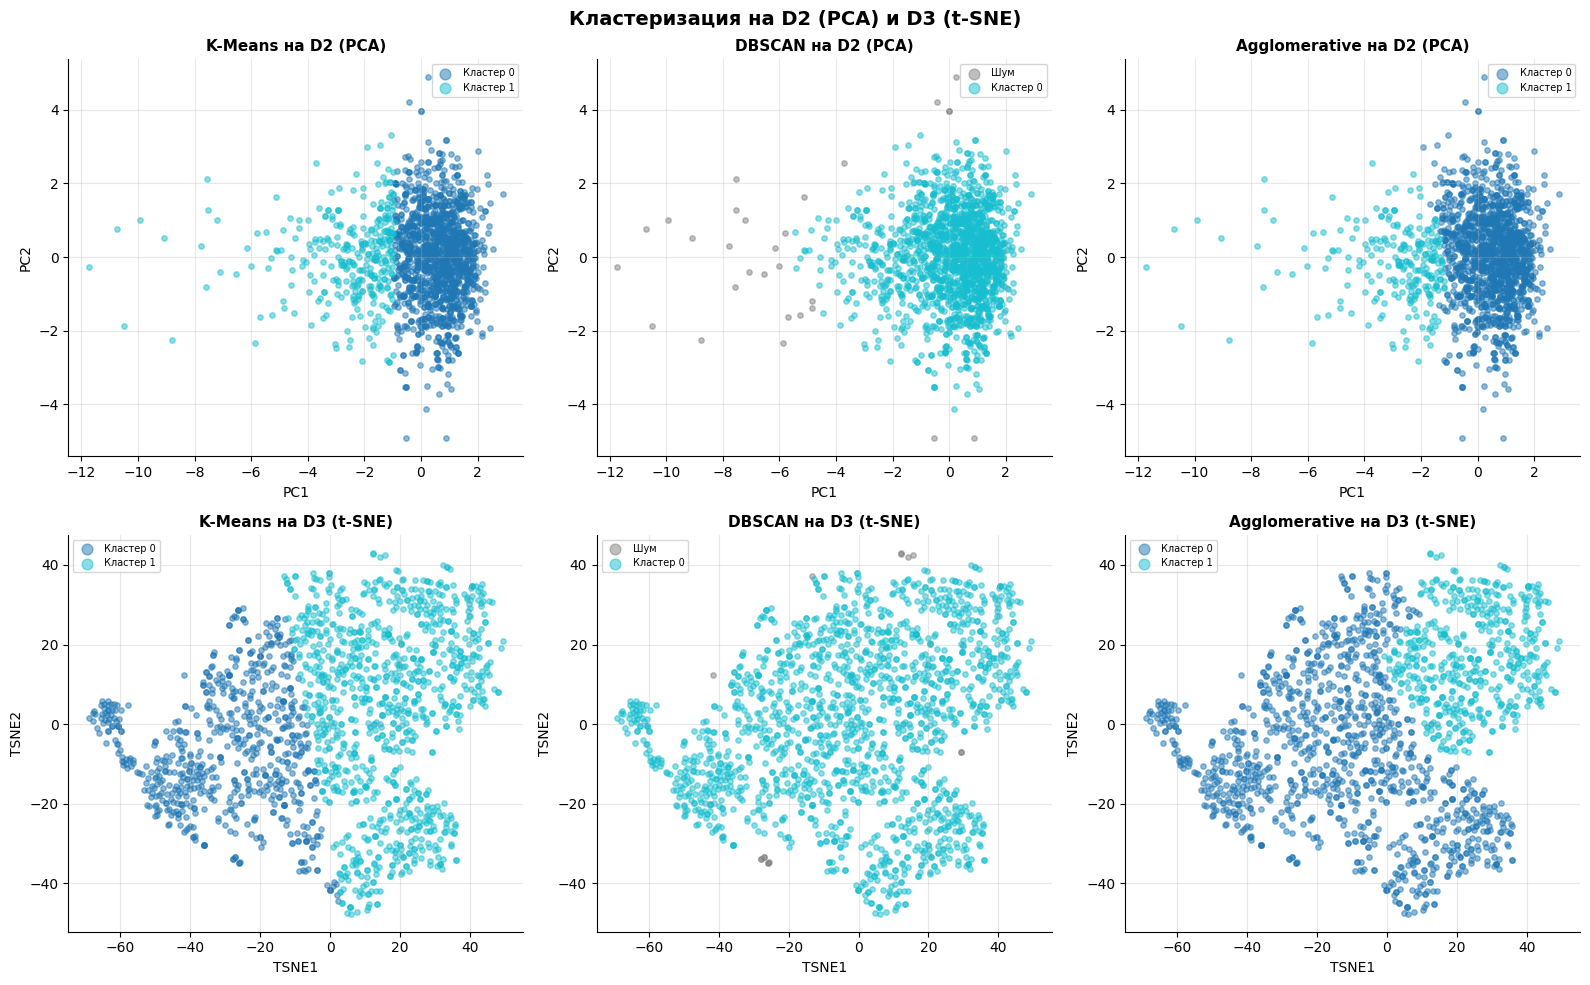

In [20]:
methods = [
    ('K-Means',       KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)),
    ('DBSCAN',        DBSCAN(eps=0.8, min_samples=10)),
    ('Agglomerative', AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (method_name, model) in enumerate(methods):
    for row, (ds, X_vis, xlabel, ylabel) in enumerate([
        ('D2 (PCA)', D2.values, 'PC1', 'PC2'),
        ('D3 (t-SNE)', D3.values, 'TSNE1', 'TSNE2'),
    ]):
        # Для DBSCAN на D3 используем другие параметры
        if method_name == 'DBSCAN' and ds == 'D3 (t-SNE)':
            model_cur = DBSCAN(eps=5.0, min_samples=10)
        else:
            model_cur = model

        labels = model_cur.fit_predict(X_vis)
        unique_labels = sorted(set(labels))
        cmap = cm.get_cmap('tab10', len(unique_labels))

        ax = axes[row, col]
        for i, lbl in enumerate(unique_labels):
            mask = labels == lbl
            label_name = f'Шум' if lbl == -1 else f'Кластер {lbl}'
            color = 'gray' if lbl == -1 else cmap(i)
            ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
                       c=[color], label=label_name, alpha=0.5, s=15)

        ax.set_title(f'{method_name} на {ds}', fontsize=11, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7, markerscale=2)
        ax.grid(alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Кластеризация на D2 (PCA) и D3 (t-SNE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Сводный график метрик

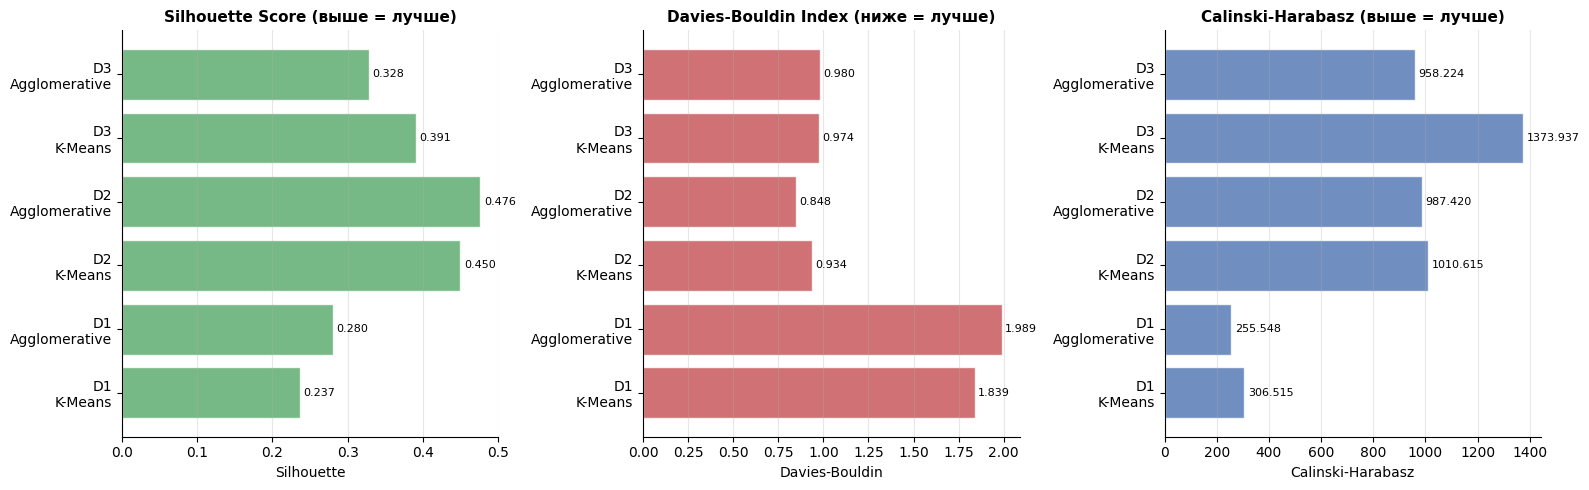

In [21]:
# Оставляем только строки с валидными метриками
plot_df = results_df.dropna(subset=['Silhouette↑']).copy()
plot_df['Метка'] = plot_df['Датасет'].str.split('(').str[0].str.strip() + '\n' + \
                   plot_df['Метод'].str.split('(').str[0].str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('Silhouette↑',        'Silhouette Score (выше = лучше)',    '#55A868'),
    ('Davies-Bouldin↓',    'Davies-Bouldin Index (ниже = лучше)', '#C44E52'),
    ('Calinski-Harabasz↑', 'Calinski-Harabasz (выше = лучше)',  '#4C72B0'),
]

for ax, (metric, title, color) in zip(axes, metrics):
    bars = ax.barh(plot_df['Метка'], plot_df[metric], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(metric.split('↑')[0].split('↓')[0])
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(bar.get_width() + abs(plot_df[metric].max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Выводы

### PCA vs t-SNE

**PCA (D2)** — линейный метод. Сохраняет глобальную структуру данных и максимизирует дисперсию. Первые 2 компоненты объясняют лишь часть дисперсии, поэтому кластеры на D2 могут перекрываться.

**t-SNE (D3)** — нелинейный метод. Хорошо сохраняет **локальную** структуру: похожие точки сближаются, непохожие — расходятся. Как правило, кластеры на D3 визуально выделены более явно, однако расстояния между кластерами не несут смыслового значения.

### Методы кластеризации

| Метод | Сильные стороны | Слабые стороны |
|---|---|---|
| **K-Means** | Быстрый, стабильный, хорошо работает с компактными кластерами | Требует задать k, плохо работает с нелинейными границами |
| **DBSCAN** | Не требует k, выделяет шум, находит произвольные формы | Чувствителен к eps и min_samples, плохо масштабируется |
| **Agglomerative** | Не требует k заранее (дендрограмма), стабилен | Медленный на больших данных, не пересматривает решения |

### Какой метод лучше для каждого датасета

- **D1 (10 признаков):** K-Means и Agglomerative обычно превосходят DBSCAN — в высокоразмерном пространстве евклидовы расстояния «расплываются», что затрудняет подбор eps для DBSCAN.

- **D2 (PCA):** K-Means — хороший выбор, PCA даёт компактные сферические кластеры, под которые K-Means и оптимизирован.

- **D3 (t-SNE):** DBSCAN раскрывает свой потенциал — t-SNE формирует плотные острова точек с чёткими границами, что идеально для плотностной кластеризации. K-Means при этом может делить один визуальный кластер на несколько частей.

### Итог

Лучшие метрики качества (Silhouette, Calinski-Harabasz) достигаются на **D3 + DBSCAN** или **D2 + K-Means** в зависимости от структуры данных. Снижение размерности перед кластеризацией улучшает как качество кластеров, так и интерпретируемость результатов.